## Analyses exploratoires 
#### la matrice de correlation, la distribution des données, 

In [12]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib

ROOT           = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

X = pd.read_parquet(DATA_PROCESSED / 'X.parquet')
Y = pd.read_parquet(DATA_PROCESSED / 'Y.parquet')
df=pd.concat([X,Y],axis=1)
print(f"X : {X.shape}")
print(f"Y : {Y.shape}")
print(f"df : {df.shape}")

X : (549971, 110)
Y : (549971, 5)
df : (549971, 115)


## La matrice de correlation entre les variables cibles

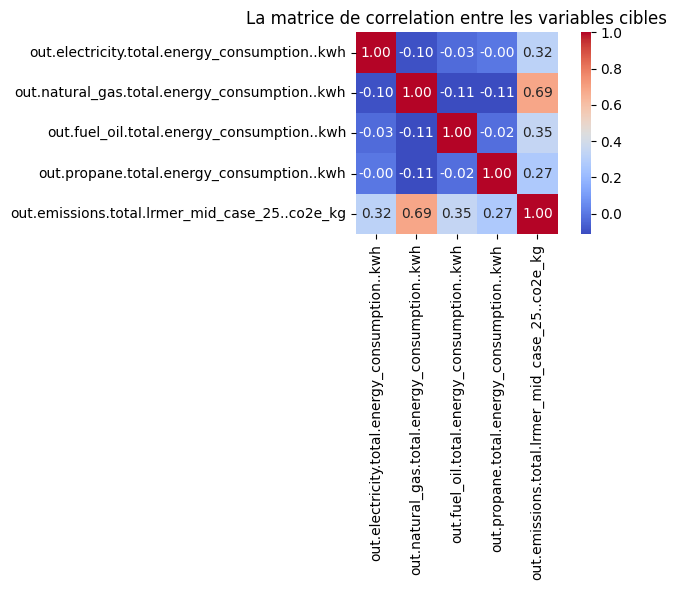

In [13]:

import seaborn as sns
import matplotlib.pyplot as plt

TARGETS = [
    'out.electricity.total.energy_consumption..kwh',
    'out.natural_gas.total.energy_consumption..kwh',
    'out.fuel_oil.total.energy_consumption..kwh',
    'out.propane.total.energy_consumption..kwh',
    'out.emissions.total.lrmer_mid_case_25..co2e_kg',
]

# Matrice de corrélation
corr_matrix = Y[TARGETS].corr(method='pearson')

# Affichage numérique
#print(corr_matrix)


plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)
plt.title('La matrice de correlation entre les variables cibles')
plt.tight_layout()
plt.show()

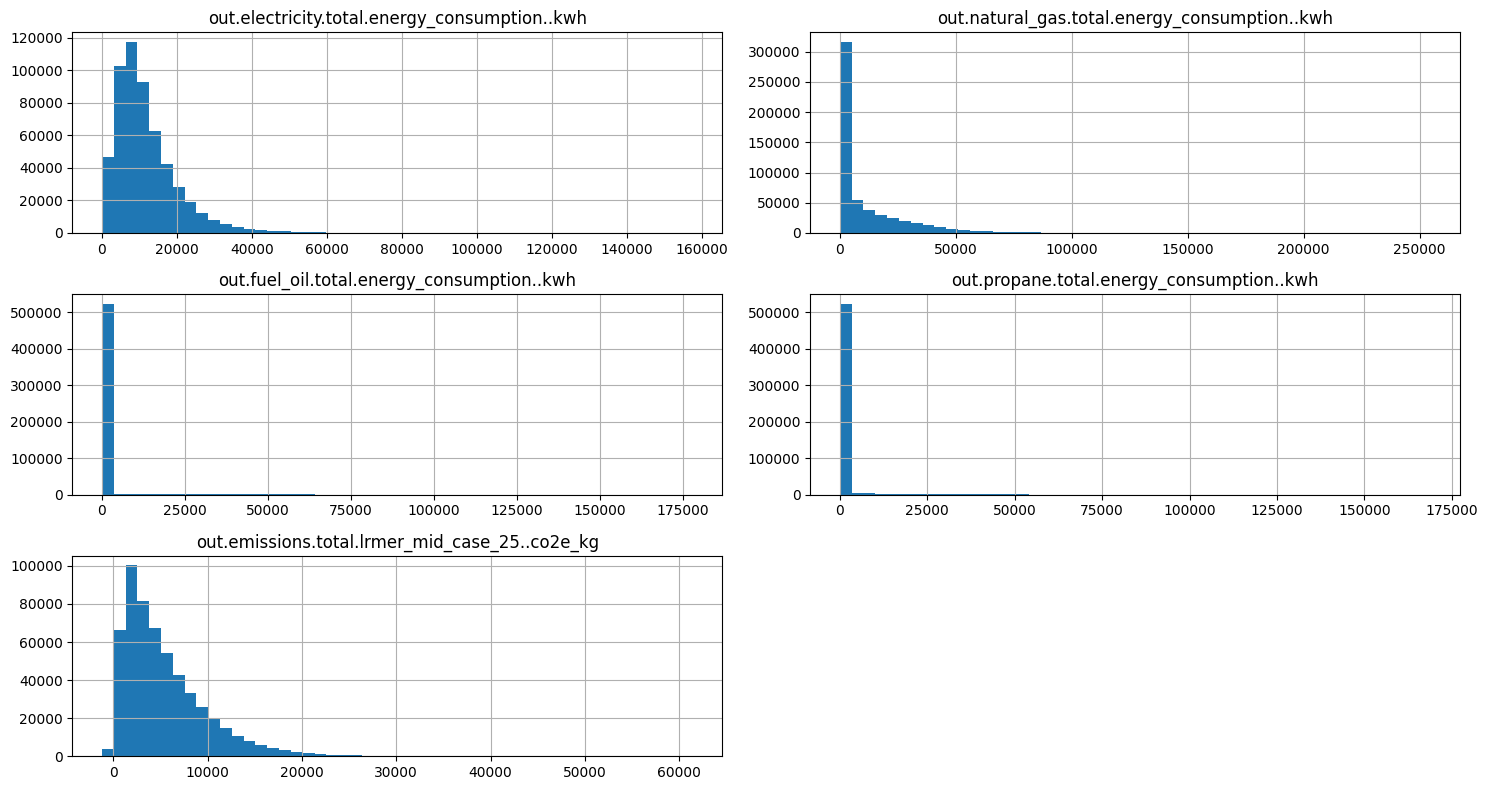

                                                   count          mean  \
out.electricity.total.energy_consumption..kwh   549971.0  11755.593726   
out.natural_gas.total.energy_consumption..kwh   549971.0  10592.467319   
out.fuel_oil.total.energy_consumption..kwh      549971.0   1280.719278   
out.propane.total.energy_consumption..kwh       549971.0   1103.602844   
out.emissions.total.lrmer_mid_case_25..co2e_kg  549971.0   5427.255224   

                                                         std          min  \
out.electricity.total.energy_consumption..kwh    8617.362758     0.000000   
out.natural_gas.total.energy_consumption..kwh   16291.322601     0.000000   
out.fuel_oil.total.energy_consumption..kwh       7065.900098     0.000000   
out.propane.total.energy_consumption..kwh        6178.112723     0.000000   
out.emissions.total.lrmer_mid_case_25..co2e_kg   4485.947041 -1194.612617   

                                                        25%          50%  \
out.electricity.

In [14]:
Y[TARGETS].hist(figsize=(15,8),bins=50)
plt.tight_layout()
plt.show()

print(Y[TARGETS].describe().T)

## Pourcentage de valeurs nulles

In [15]:
missing=Y.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Series([], dtype: int64)


## Nombre de valeurs uniques et du pourcentage de valeurs uniques

In [16]:
unique_nb=pd.DataFrame({
    'n_unique': df.nunique(),
    'pct_unique': df.nunique()/len(df)*100})
print(unique_nb.sort_values('n_unique', ascending=False).head(30))

#supprimer les colonnes avec une valeur unique 
cols_to_drop = unique_nb[unique_nb['n_unique'] == 1].index
print(f"Nombre de colonnes à supprimer : {len(cols_to_drop)}")
print(f"Colonnes à supprimer : {list(cols_to_drop)}")


                                                n_unique  pct_unique
out.emissions.total.lrmer_mid_case_25..co2e_kg    508440   92.448511
out.natural_gas.total.energy_consumption..kwh     137355   24.974953
out.electricity.total.energy_consumption..kwh     110463   20.085241
out.propane.total.energy_consumption..kwh          28490    5.180273
out.fuel_oil.total.energy_consumption..kwh         25282    4.596970
in.air_leakage_to_outside_ach50                     2586    0.470207
in.weather_file_longitude                            947    0.172191
in.weather_file_latitude                             805    0.146371
in.electric_panel_breaker_space_total_count           53    0.009637
in.plug_loads                                         31    0.005637
in.range_spot_vent_hour                               24    0.004364
in.bathroom_spot_vent_hour                            24    0.004364
in.income                                             19    0.003455
in.geometry_stories               

## Correlation des variables explicatives avec les cibles

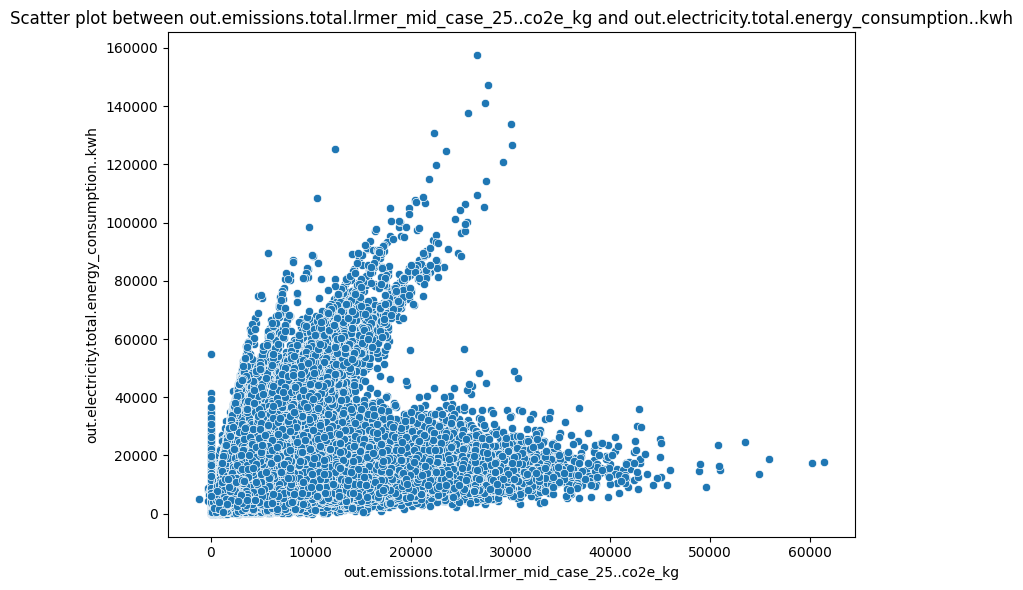

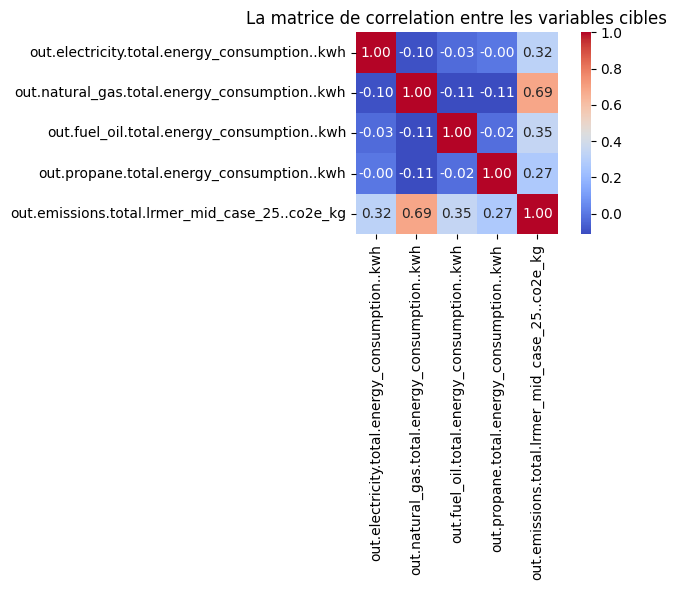

In [17]:
targets_corr = 'out.emissions.total.lrmer_mid_case_25..co2e_kg'
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[targets_corr], y=df['out.electricity.total.energy_consumption..kwh'])
plt.title(f'Scatter plot between {targets_corr} and out.electricity.total.energy_consumption..kwh')
plt.xlabel(targets_corr)
plt.ylabel('out.electricity.total.energy_consumption..kwh')
plt.tight_layout()
plt.show()

corrr_matrix = df[TARGETS].corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(
    corrr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)
plt.title('La matrice de correlation entre les variables cibles')
plt.tight_layout()
plt.show()


In [20]:

# Vérification : aucune colonne string ne doit rester 
str_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
if str_cols:
    print(f"Colonnes string résiduelles : {str_cols}")
    X.drop(columns=str_cols, inplace=True)
else:
    print("Aucune colonne string")

# Vérification NaN résiduels
nan_summary = X.isna().sum()
nan_cols = nan_summary[nan_summary > 0]
if len(nan_cols):
    print(f"\nColonnes avec NaN :\n{nan_cols}")
    # Imputation médiane de sécurité
    for col in nan_cols.index:
        X[col] = X[col].fillna(X[col].median())
    print("→ Imputés par médiane")
else:
    print("Aucun NaN")

# Séparation avant scaling
# IMPORTANT : on split D'ABORD, on scale ENSUITE
# Le scaler ne doit jamais voir X_val ni X_test

from sklearn.model_selection import train_test_split

# Split temporaire 70 / 30 (le 30 sera redécoupé en val/test à l'étape 3)
X_train_raw, X_tmp_raw, Y_train, Y_tmp = train_test_split(
    X, 
    Y,
    test_size=0.30,
    random_state=42
)
print(f"\nX_train : {X_train_raw.shape}")
print(f"X_tmp   : {X_tmp_raw.shape}  (sera découpé en val + test à l'étape 3)")

# Fit du scaler UNIQUEMENT sur X_train 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)    # fit + transform
X_tmp_sc   = scaler.transform(X_tmp_raw)          # transform uniquement

print(f"\nScaler fité sur X_train ({X_train_raw.shape[0]} lignes)")
print(f"Moyenne  (5 premières features) : {scaler.mean_[:5].round(3)}")
print(f"Std      (5 premières features) : {scaler.scale_[:5].round(3)}")

# Sauvegarde du scaler (indispensable pour l'inférence future) 
scaler_path = DATA_PROCESSED / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"\nScaler sauvegardé → {scaler_path}")


Aucune colonne string
Aucun NaN

X_train : (384979, 110)
X_tmp   : (164992, 110)  (sera découpé en val + test à l'étape 3)

Scaler fité sur X_train (384979 lignes)
Moyenne  (5 premières features) : [ 0.016  0.925 11.002  2.739  1.   ]
Std      (5 premières features) : [0.125 0.463 8.039 1.04  0.141]

Scaler sauvegardé → \\FS-SOP\Staff-CMA\yzouarhi\Bureau\Data\FlexiMax\data\processed\scaler.pkl


Calcul de l'inertie pour différents K...
  K= 10  inertie=35660775
  K= 20  inertie=32960296
  K= 30  inertie=31597620
  K= 50  inertie=28686204
  K= 75  inertie=26926214
  K=100  inertie=26070921


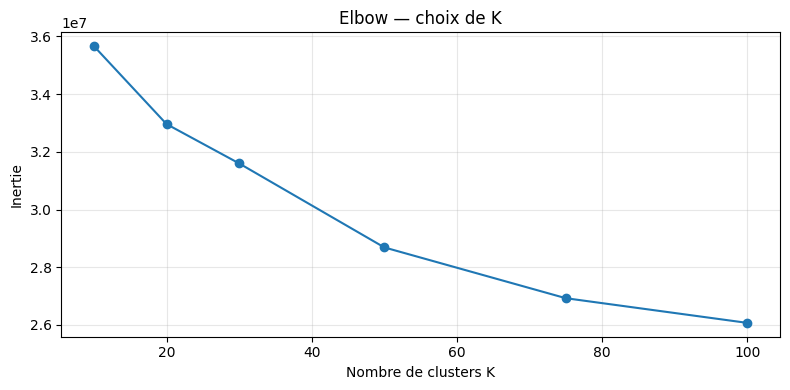

→ Choisis K là où la courbe s'aplatit (coude)


In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Trouver le bon K avec la méthode Elbow 
# On travaille sur X_train_sc (déjà normalisé)
# MiniBatchKMeans : beaucoup plus rapide que KMeans sur 550k lignes

inertias = {}
K_RANGE  = [10, 20, 30, 50, 75, 100]

print("Calcul de l'inertie pour différents K...")
for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, random_state=42,
                         batch_size=10_000, n_init=3)
    km.fit(X_train_sc)
    inertias[k] = km.inertia_
    print(f"  K={k:3d}  inertie={km.inertia_:.0f}")

plt.figure(figsize=(8, 4))
plt.plot(list(inertias.keys()), list(inertias.values()), 'o-')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Inertie')
plt.title('Elbow — choix de K')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'elbow_kmeans.png', dpi=120)
plt.show()
print("→ Choisis K là où la courbe s'aplatit (coude)")


In [ ]:
# Fit final avec le K choisi 
K_FINAL = 50   # ajuste selon le coude observé

km_final = MiniBatchKMeans(n_clusters=K_FINAL, random_state=42,
                            batch_size=10_000, n_init=5)
km_final.fit(X_train_sc)

# Assigner les clusters à chaque partition
train_clusters = km_final.predict(X_train_sc)
tmp_clusters   = km_final.predict(X_tmp_sc)

print(f"\nDistribution des clusters (X_train) :")
unique, counts = np.unique(train_clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u:3d} : {c:6d} lignes  ({c/len(train_clusters)*100:.1f}%)")

# Sauvegarde du modèle de clustering
joblib.dump(km_final, DATA_PROCESSED / 'kmeans.pkl')
print(f"\nKMeans sauvegardé → kmeans.pkl")



Distribution des clusters (X_train) :
  Cluster   0 :   7792 lignes  (2.0%)
  Cluster   1 :   9701 lignes  (2.5%)
  Cluster   2 :   2743 lignes  (0.7%)
  Cluster   3 :   6514 lignes  (1.7%)
  Cluster   4 :  13814 lignes  (3.6%)
  Cluster   5 :   6291 lignes  (1.6%)
  Cluster   6 :  14031 lignes  (3.6%)
  Cluster   7 :   5267 lignes  (1.4%)
  Cluster   8 :   4729 lignes  (1.2%)
  Cluster   9 :   5332 lignes  (1.4%)
  Cluster  10 :  11368 lignes  (3.0%)
  Cluster  11 :   8627 lignes  (2.2%)
  Cluster  12 :   6408 lignes  (1.7%)
  Cluster  13 :   6010 lignes  (1.6%)
  Cluster  14 :   3295 lignes  (0.9%)
  Cluster  15 :   8403 lignes  (2.2%)
  Cluster  16 :   4023 lignes  (1.0%)
  Cluster  17 :   9554 lignes  (2.5%)
  Cluster  18 :  11625 lignes  (3.0%)
  Cluster  19 :   9431 lignes  (2.4%)
  Cluster  20 :   2035 lignes  (0.5%)
  Cluster  21 :   6745 lignes  (1.8%)
  Cluster  22 :   2214 lignes  (0.6%)
  Cluster  23 :   4598 lignes  (1.2%)
  Cluster  24 :   6225 lignes  (1.6%)
  Cluster  

In [ ]:

#  Split val / test stratifié sur les clusters 
# X_tmp (30%) → val (15%) + test (15%)

X_val_sc, X_test_sc, Y_val, Y_test = train_test_split(
    X_tmp_sc, Y_tmp,
    test_size=0.50,
    stratify=tmp_clusters,   # ← garantit la même distribution de clusters
    random_state=42
)

print(f"\n{'Partition':<12} {'Lignes':>8} {'%':>6}")
print("-" * 28)
total = X_train_sc.shape[0] + X_val_sc.shape[0] + X_test_sc.shape[0]
for name, arr in [("Train", X_train_sc), ("Val", X_val_sc), ("Test", X_test_sc)]:
    print(f"{name:<12} {arr.shape[0]:>8}  {arr.shape[0]/total*100:>5.1f}%")

# Vérification : distribution des cibles similaire dans les 3 partitions 
print(f"\nMoyenne de Y par partition (doit être similaire) :")
print(f"{'Cible':<55} {'Train':>10} {'Val':>10} {'Test':>10}")
print("-" * 90)
for col in Y.columns:
    print(f"{col:<55} "
          f"{Y_train[col].mean():>10.1f} "
          f"{Y_val[col].mean():>10.1f} "
          f"{Y_test[col].mean():>10.1f}")
'''
# ── 5. Sauvegarde des partitions ──────────────────────────────────────────────
np.save(DATA_PROCESSED / 'X_train.npy', X_train_sc)
np.save(DATA_PROCESSED / 'X_val.npy',   X_val_sc)
np.save(DATA_PROCESSED / 'X_test.npy',  X_test_sc)

Y_train.to_parquet(DATA_PROCESSED / 'Y_train.parquet', index=False)
Y_val.to_parquet(  DATA_PROCESSED / 'Y_val.parquet',   index=False)
Y_test.to_parquet( DATA_PROCESSED / 'Y_test.parquet',  index=False)

print("\n Partitions sauvegardées :")
print(f"   X_train : {X_train_sc.shape}  →  X_train.npy")
print(f"   X_val   : {X_val_sc.shape}    →  X_val.npy")
print(f"   X_test  : {X_test_sc.shape}   →  X_test.npy")
print(f"   Y_train / Y_val / Y_test      →  .parquet")
'''


Partition      Lignes      %
----------------------------
Train          384979   70.0%
Val             82496   15.0%
Test            82496   15.0%

Moyenne de Y par partition (doit être similaire) :
Cible                                                        Train        Val       Test
------------------------------------------------------------------------------------------
out.electricity.total.energy_consumption..kwh              11750.2    11784.5    11751.9
out.natural_gas.total.energy_consumption..kwh              10600.1    10564.7    10584.8
out.fuel_oil.total.energy_consumption..kwh                  1272.5     1299.4     1300.5
out.propane.total.energy_consumption..kwh                   1104.2     1113.0     1091.6
out.emissions.total.lrmer_mid_case_25..co2e_kg              5425.7     5434.1     5427.7


'\n# ── 5. Sauvegarde des partitions ──────────────────────────────────────────────\nnp.save(DATA_PROCESSED / \'X_train.npy\', X_train_sc)\nnp.save(DATA_PROCESSED / \'X_val.npy\',   X_val_sc)\nnp.save(DATA_PROCESSED / \'X_test.npy\',  X_test_sc)\n\nY_train.to_parquet(DATA_PROCESSED / \'Y_train.parquet\', index=False)\nY_val.to_parquet(  DATA_PROCESSED / \'Y_val.parquet\',   index=False)\nY_test.to_parquet( DATA_PROCESSED / \'Y_test.parquet\',  index=False)\n\nprint("\n Partitions sauvegardées :")\nprint(f"   X_train : {X_train_sc.shape}  →  X_train.npy")\nprint(f"   X_val   : {X_val_sc.shape}    →  X_val.npy")\nprint(f"   X_test  : {X_test_sc.shape}   →  X_test.npy")\nprint(f"   Y_train / Y_val / Y_test      →  .parquet")\n'